INSTALLATIONS

In [ ]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 52.2 MB/s eta 0:00:00


DATA CLEANING

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/fraud_detection/dataset/creditcard.csv')

In [ ]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
print("percent of fraud data = ",float(df['Class'].mean()*100),"percent")
print("percent of legit data = ",100 - float(df['Class'].mean()*100),"percent")

percent of fraud data =  0.1727485630620034 percent
percent of legit data =  99.827251436938 percent


In [ ]:
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

In [ ]:
print('ratio (legit:fraud) =',len(legit)/len(fraud))

ratio (legit:fraud) = 577.8760162601626


In [ ]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Class Imbalance ratio 578:1 ')

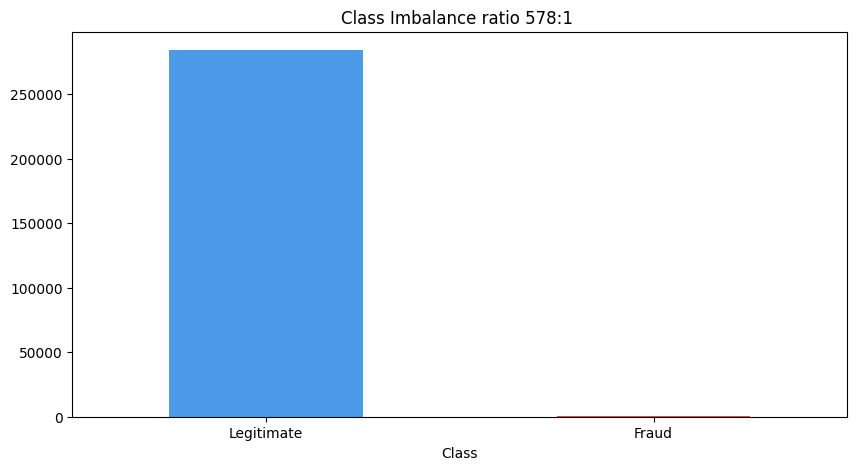

In [ ]:
fig,ax = plt.subplots(figsize = (10,5))
df['Class'].value_counts().plot(kind = 'bar', ax = ax,color=['#4C9BE8','#E84C4C'])
ax.set_xticklabels(['Legitimate','Fraud'],rotation= 0)
ax.set_title('Class Imbalance ratio 578:1 ')

In [ ]:
print('fraud data - \n count:',fraud['Class'].count(),"\n Description: \n",fraud.describe())

fraud data - 
 count: 492 
 Description: 
                 Time          V1          V2          V3          V4  \
count     492.000000  492.000000  492.000000  492.000000  492.000000   
mean    80746.806911   -4.771948    3.623778   -7.033281    4.542029   
std     47835.365138    6.783687    4.291216    7.110937    2.873318   
min       406.000000  -30.552380   -8.402154  -31.103685   -1.313275   
25%     41241.500000   -6.036063    1.188226   -8.643489    2.373050   
50%     75568.500000   -2.342497    2.717869   -5.075257    4.177147   
75%    128483.000000   -0.419200    4.971257   -2.276185    6.348729   
max    170348.000000    2.132386   22.057729    2.250210   12.114672   

               V5          V6          V7          V8          V9  ...  \
count  492.000000  492.000000  492.000000  492.000000  492.000000  ...   
mean    -3.151225   -1.397737   -5.568731    0.570636   -2.581123  ...   
std      5.372468    1.858124    7.206773    6.797831    2.500896  ...   
min    -22.1

In [ ]:
print('legit data -  \n count: ',legit['Class'].count(),"\n Description: \n",legit.describe())

legit data -  
 count:  284315 
 Description: 
                 Time             V1             V2             V3  \
count  284315.000000  284315.000000  284315.000000  284315.000000   
mean    94838.202258       0.008258      -0.006271       0.012171   
std     47484.015786       1.929814       1.636146       1.459429   
min         0.000000     -56.407510     -72.715728     -48.325589   
25%     54230.000000      -0.917544      -0.599473      -0.884541   
50%     84711.000000       0.020023       0.064070       0.182158   
75%    139333.000000       1.316218       0.800446       1.028372   
max    172792.000000       2.454930      18.902453       9.382558   

                  V4             V5             V6             V7  \
count  284315.000000  284315.000000  284315.000000  284315.000000   
mean       -0.007860       0.005453       0.002419       0.009637   
std         1.399333       1.356952       1.329913       1.178812   
min        -5.683171    -113.743307     -26.160506    

In [ ]:
fraud['Amount'].describe()

,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


In [ ]:
legit['Amount'].describe()

,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


In [ ]:
import numpy as np

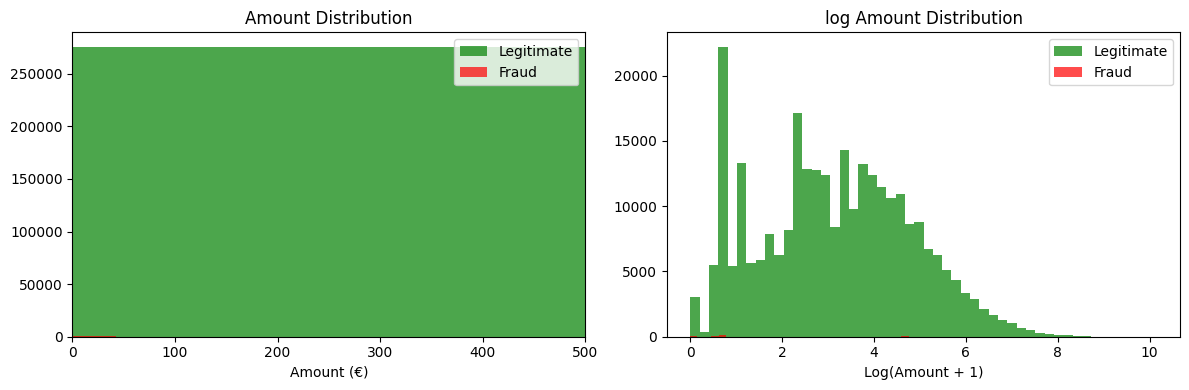

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(legit['Amount'], bins = 50, color = 'green',alpha=0.7, label='Legitimate')
axes[0].hist(fraud['Amount'], bins = 50, color = 'red',alpha=0.7, label='Fraud')
axes[0].set_title("Amount Distribution")
axes[0].set_xlabel('Amount (€)')
axes[0].legend()
axes[0].set_xlim(0, 500)
axes[1].hist(np.log1p(legit['Amount']),bins = 50, color = 'green',alpha=0.7, label='Legitimate')
axes[1].hist(np.log1p(fraud['Amount']),bins = 50, color = 'red',alpha=0.7, label='Fraud')
axes[1].set_title("log Amount Distribution")
axes[1].set_xlabel('Log(Amount + 1)')
axes[1].legend()
plt.tight_layout()


fraud transactions in very small amounts (from above graphs)

TIME CONVERSION TO HOUR

Text(0, 0.5, 'volume')

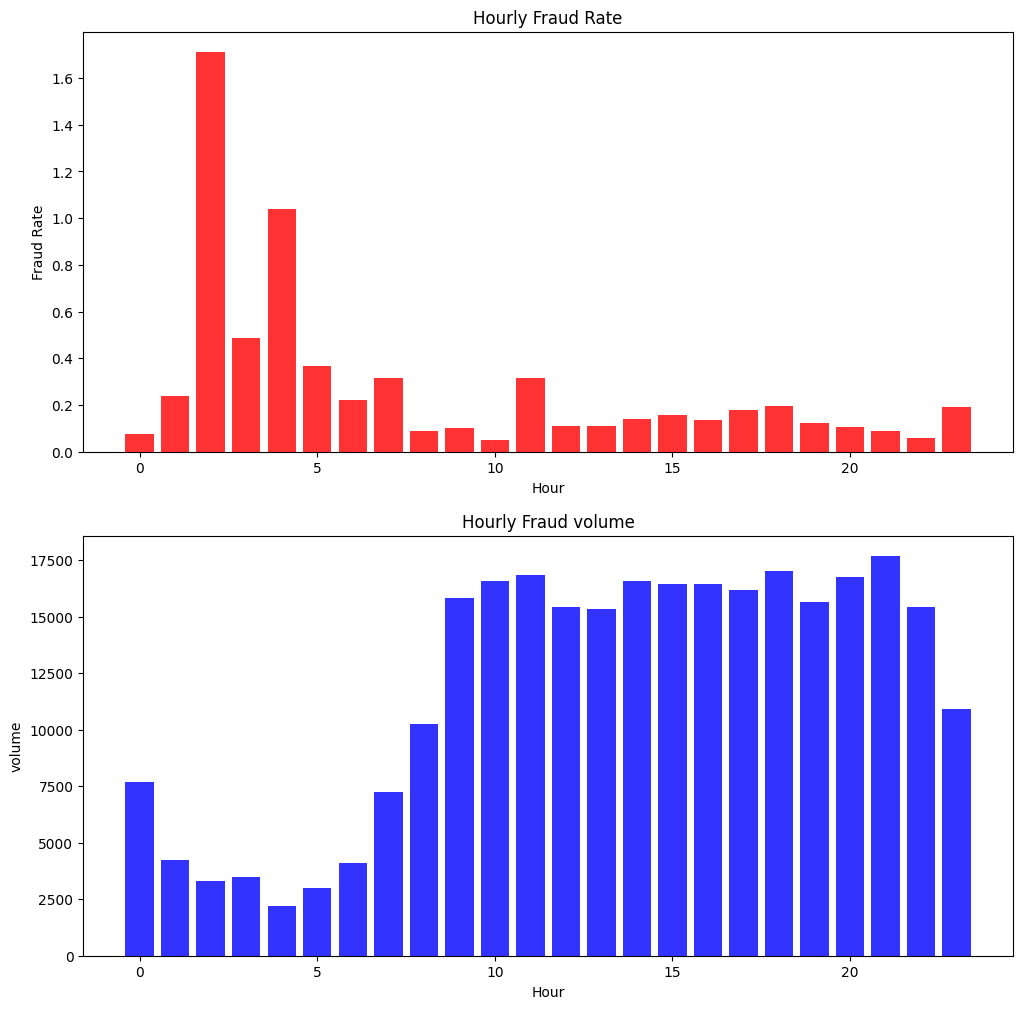

In [ ]:
df['hour'] = (df['Time']//3600)%24
hourly_fraud_rate = df.groupby('hour')['Class'].mean()
hourly_volume = df.groupby('hour')['Class'].count()
fig, axes = plt.subplots(2, 1, figsize=(12,12))
axes[0].bar(hourly_fraud_rate.index, hourly_fraud_rate.values * 100, color='red', alpha=0.8)
axes[0].set_title("Hourly Fraud Rate")
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Fraud Rate')
axes[1].bar(hourly_volume.index, hourly_volume.values, color='blue', alpha=0.8)
axes[1].set_title("Hourly Fraud volume")
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('volume')


max fraud transactions between 2-5 am and that is the time when min no. of volume

Feature seperation analysis

['V3', 'V14', 'V17', 'V12']


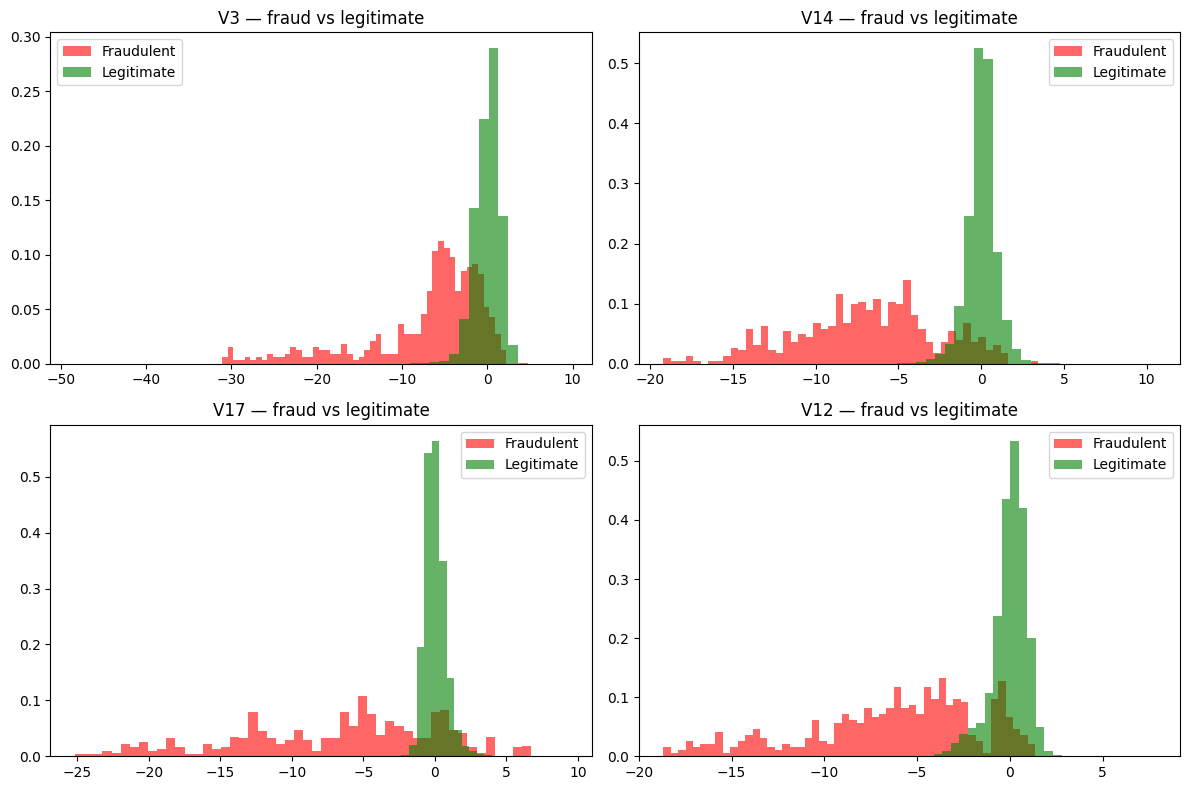

In [ ]:
fraud_means = fraud[['V'+ str(i) for i in range(1,29)]].mean()
legit_means = legit[['V'+ str(i) for i in range(1,29)]].mean()
difference = (fraud_means - legit_means).abs().sort_values(ascending=False)
top_features = difference.head(4).index.tolist()
print(top_features)
fig, axes = plt.subplots(2, 2, figsize=(12,8))
for i, feat in enumerate(top_features):
  ax = axes[i//2][i%2]
  ax.hist(fraud[feat], bins = 50, color = 'red',density = True, alpha=0.6, label = 'Fraudulent')
  ax.hist(legit[feat], bins = 50, color = 'green',density = True, alpha=0.6, label = 'Legitimate')
  ax.set_title(f'{feat} — fraud vs legitimate')
  ax.legend()
plt.tight_layout()





we can see above minimum overlaps they have a clearly different distributions

SCALING

In [ ]:
from sklearn.model_selection import train_test_split
x = df.drop(['Class'],axis = 1)
Y = df['Class']
X_Train, X_Test, Y_Train, Y_Test = train_test_split(x, Y, test_size= 0.2, random_state=42,
    stratify=Y )
print(f"Train size: {len(X_Train):,}")
print(f"Test size:  {len(X_Test):,}")
print(f"Train fraud count: {Y_Train.sum()}")
print(f"Test fraud count:  {Y_Test.sum()}")
print(f"Train fraud rate: {Y_Train.mean()*100:.3f}%")
print(f"Test fraud rate:  {Y_Test.mean()*100:.3f}%")

Train size: 227,845
Test size:  56,962
Train fraud count: 394
Test fraud count:  98
Train fraud rate: 0.173%
Test fraud rate:  0.172%


In [ ]:
X_Train


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,hour
265518,161919.0,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,...,0.076197,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,7.32,20.0
180305,124477.0,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,...,0.038628,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,2.99,10.0
42664,41191.0,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,...,-2.798352,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,175.10,11.0
198723,132624.0,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,...,-0.139670,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,6.10,12.0
82325,59359.0,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,...,-0.243245,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,86.10,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233802,147710.0,1.993864,-0.516866,-0.620118,0.129845,-0.285128,0.395044,-0.822358,0.231591,0.995898,...,0.262526,0.884510,0.099141,0.275689,-0.195404,0.623598,-0.032455,-0.058552,5.99,17.0
85418,60764.0,-1.497933,0.657921,1.581568,-0.024286,0.584698,1.303031,0.609212,0.135561,0.452745,...,-0.072452,0.299172,0.110048,-0.615980,-0.425883,0.263968,-0.448445,0.045178,36.99,16.0
29062,35301.0,1.069777,0.072105,0.496540,1.505318,-0.380277,-0.370243,0.100551,-0.026687,0.319684,...,-0.061991,-0.044629,-0.050485,0.400171,0.593314,-0.335160,0.031014,0.024886,45.42,9.0
13766,24413.0,1.280465,0.300586,0.333044,0.512720,0.065052,-0.145844,-0.145519,-0.091833,1.111187,...,-0.409934,-0.961351,0.033153,-0.560429,0.278428,0.089546,-0.059835,-0.005887,0.89,6.0


In [ ]:
from sklearn.preprocessing import RobustScaler,StandardScaler
scaler = RobustScaler()
X_Train['Amount_scaled'] = scaler.fit_transform(X_Train['Amount'].values.reshape(-1,1))
X_Test['Amount_scaled'] = scaler.transform(X_Test['Amount'].values.reshape(-1,1))
X_Train = X_Train.drop(['Amount'],axis = 1)
X_Test = X_Test.drop(['Amount'],axis = 1)
X_Train = X_Train.drop(['Time'],axis = 1)
X_Test = X_Test.drop(['Time'],axis = 1)

In [ ]:
X_Train


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,hour,Amount_scaled
265518,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,-0.157403,...,0.076197,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,20.0,-0.204315
180305,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,0.284864,...,0.038628,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,10.0,-0.264579
42664,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,-2.009561,...,-2.798352,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,11.0,2.130828
198723,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,1.756121,...,-0.139670,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,12.0,-0.221294
82325,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,-0.558955,...,-0.243245,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,16.0,0.892136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233802,1.993864,-0.516866,-0.620118,0.129845,-0.285128,0.395044,-0.822358,0.231591,0.995898,0.212619,...,0.262526,0.884510,0.099141,0.275689,-0.195404,0.623598,-0.032455,-0.058552,17.0,-0.222825
85418,-1.497933,0.657921,1.581568,-0.024286,0.584698,1.303031,0.609212,0.135561,0.452745,0.108640,...,-0.072452,0.299172,0.110048,-0.615980,-0.425883,0.263968,-0.448445,0.045178,16.0,0.208629
29062,1.069777,0.072105,0.496540,1.505318,-0.380277,-0.370243,0.100551,-0.026687,0.319684,-0.131553,...,-0.061991,-0.044629,-0.050485,0.400171,0.593314,-0.335160,0.031014,0.024886,9.0,0.325957
13766,1.280465,0.300586,0.333044,0.512720,0.065052,-0.145844,-0.145519,-0.091833,1.111187,-0.268878,...,-0.409934,-0.961351,0.033153,-0.560429,0.278428,0.089546,-0.059835,-0.005887,6.0,-0.293807


In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_Train, Y_Train)
print("before smote fraud :" ,Y_Train.mean()*100,"%")
print("after smote fraud :" ,y_train_smote.mean()*100,"%")

before smote fraud : 0.17292457591783889 %
after smote fraud : 50.0 %


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, roc_auc_score, classification_report,
    precision_recall_curve)
lr = LogisticRegression(class_weight='balanced')
lr.fit(X_Train, Y_Train)
lr_probs = lr.predict_proba(X_Test)[:, 1]
lr_auc_roc = roc_auc_score(Y_Test, lr_probs)
lr_auc_pr = average_precision_score(Y_Test, lr_probs)
print('Logistic: ROC AUC=%.3f, AP=%.3f' % (lr_auc_roc, lr_auc_pr))

Logistic: ROC AUC=0.972, AP=0.723


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from xgboost import XGBClassifier
neg = (Y_Train == 0).sum()
pos = (Y_Train == 1).sum()
ratio = neg/pos
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=ratio,   # handles imbalance
    eval_metric='aucpr',      # optimise for PR, not accuracy
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1                 # use all CPU cores
)
eval_set = [(X_Test, Y_Test)]
xgb.fit(
    X_Train, Y_Train,
    eval_set=eval_set,
    verbose=50  # print every 50 rounds
)
xgb_probs = xgb.predict_proba(X_Test)[:,1]
xgb_auc_roc = roc_auc_score(Y_Test, xgb_probs)
xgb_auc_pr  = average_precision_score(Y_Test, xgb_probs)
print(f"\nXGBoost:")
print(f"  AUC-ROC: {xgb_auc_roc:.4f}")
print(f"  AUC-PR:  {xgb_auc_pr:.4f}")
print(f"\nImprovement over LR: {(xgb_auc_pr - lr_auc_pr)*100:.1f}%")

[0]	validation_0-aucpr:0.45567


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:46:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[50]	validation_0-aucpr:0.71635
[100]	validation_0-aucpr:0.81100
[150]	validation_0-aucpr:0.84744
[200]	validation_0-aucpr:0.86483
[250]	validation_0-aucpr:0.87093
[299]	validation_0-aucpr:0.87344

XGBoost:
  AUC-ROC: 0.9720
  AUC-PR:  0.8736

Improvement over LR: 15.0%


In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np
precision, recall, thresholds = precision_recall_curve(Y_Test, xgb_probs)
#finding the best threshold value by f1 score
f1_scores = (2 * precision * recall) / (precision + recall)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]

print(f"Optimal threshold: {best_threshold:.4f}")
print(f"At this threshold:")
print(f"  Precision: {precision[best_threshold_idx]:.3f}")
print(f"  Recall:    {recall[best_threshold_idx]:.3f}")
print(f"  F1-score:  {f1_scores[best_threshold_idx]:.3f}")

y_pred_optimal = (xgb_probs >= best_threshold).astype(int)
print("\nClassification report at optimal threshold:")
print(classification_report(Y_Test, y_pred_optimal,
      target_names=['Legitimate','Fraud']))


Optimal threshold: 0.5104
At this threshold:
  Precision: 0.875
  Recall:    0.857
  F1-score:  0.866

Classification report at optimal threshold:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.88      0.86      0.87        98

    accuracy                           1.00     56962
   macro avg       0.94      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962



Text(0.5, 1.0, 'Confusion Matrix')

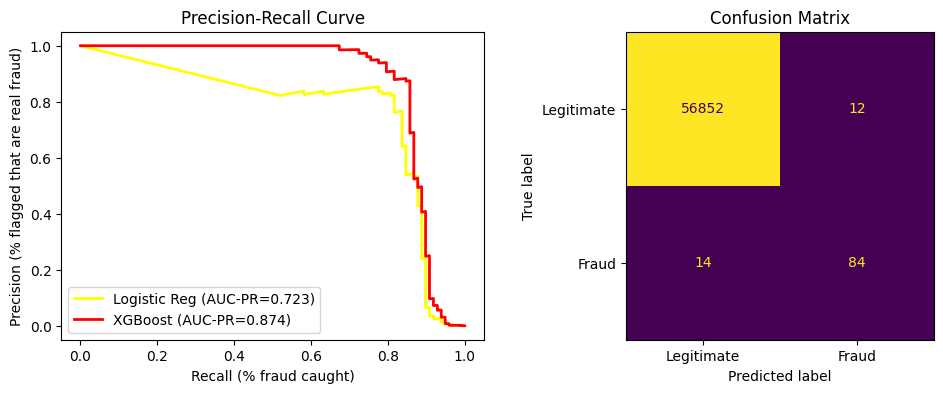

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(12,4))
lr_p, lr_r, _ = precision_recall_curve(Y_Test, lr_probs)
xgb_p, xgb_r, _ = precision_recall_curve(Y_Test, xgb_probs)
axes[0].plot(lr_r, lr_p, color='yellow',
             label=f'Logistic Reg (AUC-PR={lr_auc_pr:.3f})',
             linewidth=2)
axes[0].plot(xgb_r, xgb_p, color = 'red', label = f'XGBoost (AUC-PR={xgb_auc_pr:.3f})',
             linewidth=2)
axes[0].set_xlabel('Recall (% fraud caught)')
axes[0].set_ylabel('Precision (% flagged that are real fraud)')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(Y_Test, y_pred_optimal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate','Fraud'])
disp.plot(ax = axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix')


BUSINESS IMPACT CALCULATION

In [ ]:
# Business impact calculation
cm = confusion_matrix(Y_Test, y_pred_optimal)
tn, fp, fn, tp = cm.ravel()

avg_fraud_amount = fraud['Amount'].mean()
avg_legit_amount = legit['Amount'].mean()

fraud_caught_value = tp * avg_fraud_amount
fraud_missed_value = fn * avg_fraud_amount
legit_blocked_count = fp

print("=" * 50)
print("BUSINESS IMPACT SUMMARY")
print("=" * 50)
print(f"\nFraud transactions in test set: {tp + fn}")
print(f"  Caught by model:  {tp} ({tp/(tp+fn)*100:.1f}% recall)")
print(f"  Missed by model:  {fn} ({fn/(tp+fn)*100:.1f}%)")
print(f"\nEstimated fraud value CAUGHT:  €{fraud_caught_value:,.2f}")
print(f"Estimated fraud value MISSED:  €{fraud_missed_value:,.2f}")
print(f"\nLegitimate transactions BLOCKED: {fp}")
print(f"  (These are unhappy customers)")
print(f"\nPrecision: {tp/(tp+fp)*100:.1f}% of flagged = real fraud")
print("=" * 50)

BUSINESS IMPACT SUMMARY

Fraud transactions in test set: 98
  Caught by model:  84 (85.7% recall)
  Missed by model:  14 (14.3%)

Estimated fraud value CAUGHT:  €10,265.75
Estimated fraud value MISSED:  €1,710.96

Legitimate transactions BLOCKED: 12
  (These are unhappy customers)

Precision: 87.5% of flagged = real fraud


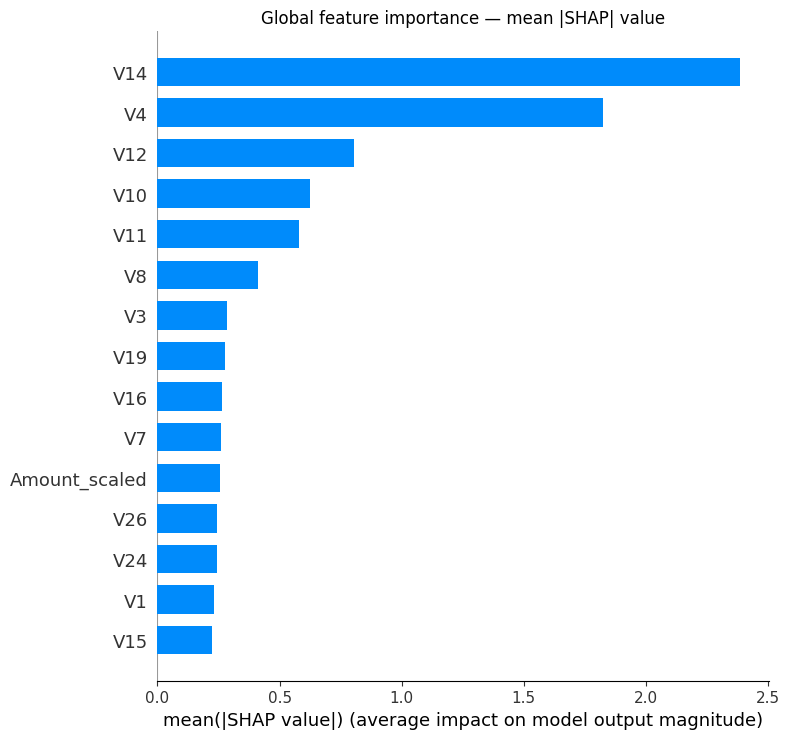

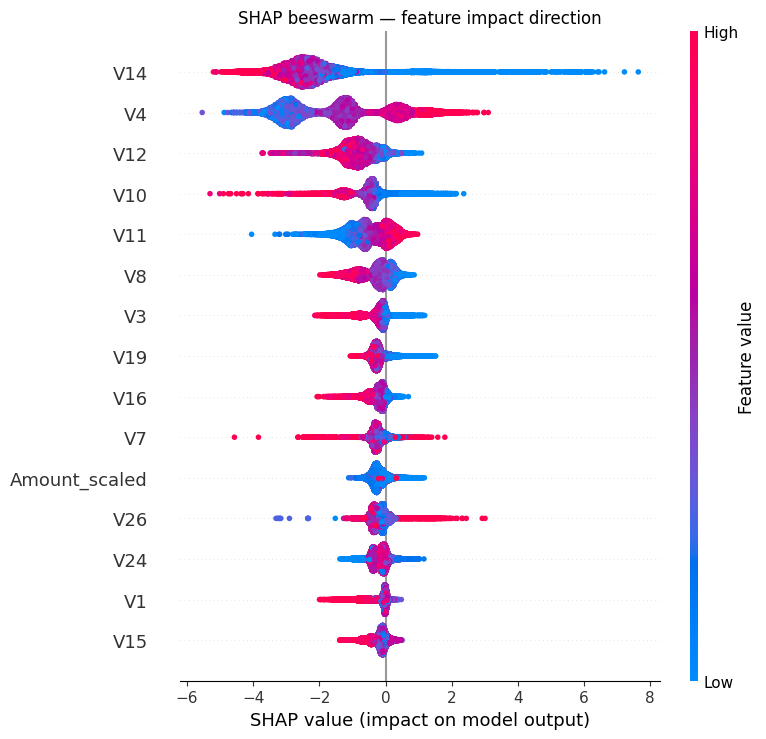

In [ ]:
import shap
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_Test)
plt.figure(figsize=(12,8))
shap.summary_plot(shap_values, X_Test, plot_type="bar",
                  max_display=15,
                  show=False)
plt.title("Global feature importance — mean |SHAP| value")
plt.tight_layout()
plt.show()
plt.figure(figsize=(12,8))
shap.summary_plot(shap_values, X_Test,
                  max_display=15,
                  show=False)
plt.title("SHAP beeswarm — feature impact direction")
plt.tight_layout()
plt.show()


In [ ]:
import joblib
import json

# Save trained XGBoost model
joblib.dump(xgb, 'fraud_model.pkl')

# Save scaler
joblib.dump(scaler, 'scaler.pkl')

# Save metadata
meta = {
    "optimal_threshold": float(best_threshold),
    "features": list(X_Train.columns)
}

with open('meta.json', 'w') as f:
    json.dump(meta, f)

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
import joblib, json, numpy as np
import json
app = FastAPI(title = "Fraud Detection API")
model = joblib.load('fraud_model.pkl')
scaler = joblib.load('scaler.pkl')
meta = json.load(open('meta.json'))
class Transaction(BaseModel):
      V1: float; V2: float; V3: float; V4: float
      V5: float; V6: float; V7: float; V8: float
      V9: float; V10: float; V11: float; V12: float
      V13: float; V14: float; V15: float; V16: float
      V17: float; V18: float; V19: float; V20: float
      V21: float; V22: float; V23: float; V24: float
      V25: float; V26: float; V27: float; V28: float
      Amount: float
      Hour: int
@app.get("/")
def home():
  return {"status": "Backend Running"}
@app.post("/predict")
def predict(txn: Transaction):
  data = txn.dict()
  data['Amount_scaled'] = scaler.transform([[data.pop('Amount')]])[0][0]
  data['features'] = [data[f] for f in meta['features']]
  prob = model.predict_proba([features])[0][1]

  return {
        "fraud_probability": round(float(prob), 4),
        "risk_level": "HIGH" if prob > THRESHOLD else "LOW",
        "verdict": "BLOCK" if prob > THRESHOLD else "ALLOW"
    }






In [ ]:
%%writefile streamlit_app.py
import streamlit as st
import requests
st.title("💳 Fraud Detection System")
amount = st.number_input("Transaction Amount")
hour = st.number_input("Hour (0-23)", min_value = 0, max_value = 23)
features = {}
for i in range(1,29):
  features[f"V{i}"] = st.number_input(f"V{i}")
if st.button("Check Fraud"):
  payload = {
      **features,
      "Amount": amount,
      "Hour": hour
  }
  res = requests.post("http://127.0.0.1:8000/predict", json=payload)
  if res.status_code == 200:
    data = res.json()

    st.subheader('Result')
    st.write(f"Fraud Probability: {data['fraud_probability']}")
    st.write(f"Risk Level: {data['risk_level']}")
    st.write(f"Verdict: {data['verdict']}")
    if data['risk_level'] == "HIGH":
      st.error("🚨 High Risk Transaction")
    else:
      st.success("✅ Safe Transaction")
    else:
      st.error("API Error")





Writing streamlit_app.py
